<a href="https://colab.research.google.com/github/manuelnunez-design/mi_primer_repositorio/blob/main/notebook_random_forest_crop_recommendation_dataset_directo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div align="center">

<img src="https://logowik.com/content/uploads/images/universidad-tecmilenio9655.jpg" width="220">

# Gestión de Proyectos de Inteligencia Artificial

## Actividad 4

### SmartCrop AI: Sistema Inteligente de Recomendación de Cultivos

#### Evaluación individual del modelo: **Random Forest**

---

| Información | Detalle |
|------------|---------|
| **Alumno(a)** | Jesús Manuel Núñez López |
| **Matrícula** | AL07145363 |
| **Docente** | M. en C. Luis Ariel Vázquez Piña |
| **Materia** | Gestión de Proyectos de Inteligencia Artificial |
| **Actividad** | Actividad 4 |
| **Fecha de entrega** | 14 / 06 / 2026 |

---

### Universidad Tecmilenio  
#### Master en Inteligencia Artificial

</div>



# Objetivo del notebook

Este notebook implementa y evalúa de forma individual el modelo **Random Forest** para un caso de uso de agricultura inteligente.

El objetivo es recomendar el cultivo más adecuado a partir de variables agroclimáticas y de fertilidad del suelo:

- Nitrógeno, fósforo y potasio.
- Temperatura.
- Humedad.
- pH del suelo.
- Lluvia.

El desempeño del modelo se evalúa mediante:

- Accuracy.
- Precision macro.
- Recall macro.
- F1-score macro.
- Latencia promedio de inferencia.
- Matriz de confusión.
- Reporte de clasificación por cultivo.


## 1. Configuración del entorno y GPU

In [1]:

import torch

print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nombre de GPU:", torch.cuda.get_device_name(0))
else:
    print("No se detectó GPU. El notebook también puede ejecutarse en CPU.")


GPU disponible: False
No se detectó GPU. El notebook también puede ejecutarse en CPU.


## 2. Instalación de dependencias

In [2]:

!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib huggingface_hub datasets


## 3. Autenticación opcional en Hugging Face Hub

In [ ]:

# Esta celda es opcional. Úsala si deseas subir el modelo o dataset a Hugging Face Hub.
# from huggingface_hub import notebook_login
# notebook_login()



## 4. Carga del dataset

En esta sección se carga el archivo `Crop_recommendation_sample.csv`, el cual contiene las variables agroclimáticas y de fertilidad del suelo necesarias para entrenar el modelo de recomendación de cultivos.

El archivo debe estar disponible en el entorno de ejecución de Google Colab.


In [3]:

import pandas as pd

# Carga del dataset
# Asegúrate de que el archivo Crop_recommendation_sample.csv esté en el entorno de Colab.
# Puedes subirlo desde el panel lateral de archivos de Colab o montarlo desde Google Drive.

df = pd.read_csv("Crop_recommendation_sample.csv")

df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,29,14,11,13.794,94.300,6.788,116.005,orange
1,25,29,27,27.964,92.370,6.229,176.416,coconut
2,29,77,27,34.129,62.842,7.399,76.607,blackgram
3,113,9,55,29.095,93.250,6.454,21.142,muskmelon
4,6,12,7,12.200,91.226,6.859,115.256,orange


## 5. Exploración inicial del dataset

In [4]:

print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nDistribución de cultivos:")
display(df["label"].value_counts().sort_index())

display(df.describe())


Dimensiones del dataset: (2200, 8)

Columnas:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Distribución de cultivos:


,count
label,
apple,100
banana,100
blackgram,100
chickpea,100
coconut,100
coffee,100
cotton,100
grapes,100
jute,100


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,51.415000,53.259545,50.206818,25.689405,72.329977,6.447179,105.752651
std,36.720545,32.676768,49.780340,5.035585,20.777984,0.714632,55.303052
min,0.000000,5.000000,5.000000,8.464000,15.313000,3.623000,20.149000
25%,22.000000,28.000000,25.000000,22.764000,61.197500,6.030000,66.095250
50%,37.000000,51.000000,33.000000,25.358000,78.947000,6.442000,96.784000
75%,86.000000,68.000000,50.000000,28.476250,90.036250,6.932000,128.033750
max,140.000000,145.000000,205.000000,43.944000,99.898000,8.993000,298.237000


## 6. Preparación de variables

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop("label", axis=1)
y_text = df["label"]

encoder = LabelEncoder()
y = encoder.fit_transform(y_text)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)
print("Número de cultivos:", len(encoder.classes_))


Tamaño de entrenamiento: (1760, 7)
Tamaño de prueba: (440, 7)
Número de cultivos: 22


## 7. Entrenamiento del modelo Random Forest

In [6]:

from sklearn.ensemble import RandomForestClassifier

model_name = "Random Forest"
safe_model_name = "random_forest"

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Modelo entrenado:", model_name)


Modelo entrenado: Random Forest


## 8. Evaluación del modelo

In [7]:

import time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predicción y medición de latencia
start_time = time.time()
y_pred = model.predict(X_test)
end_time = time.time()

total_latency = end_time - start_time
latency_per_sample = total_latency / len(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

metrics_df = pd.DataFrame({
    "Modelo": [model_name],
    "Accuracy": [accuracy],
    "Precision_macro": [precision],
    "Recall_macro": [recall],
    "F1_macro": [f1],
    "Latencia_total_seg": [total_latency],
    "Latencia_promedio_seg_muestra": [latency_per_sample]
})

display(metrics_df)


,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro,Latencia_total_seg,Latencia_promedio_seg_muestra
0,Random Forest,0.993182,0.993279,0.993182,0.993178,0.122835,0.000279


## 9. Reporte de clasificación por cultivo

In [8]:

report = classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


,precision,recall,f1-score,support
apple,1.000000,1.000000,1.000000,20.000000
banana,1.000000,1.000000,1.000000,20.000000
blackgram,1.000000,1.000000,1.000000,20.000000
chickpea,1.000000,1.000000,1.000000,20.000000
coconut,1.000000,1.000000,1.000000,20.000000
coffee,1.000000,1.000000,1.000000,20.000000
cotton,1.000000,1.000000,1.000000,20.000000
grapes,1.000000,1.000000,1.000000,20.000000
jute,0.904762,0.950000,0.926829,20.000000
kidneybeans,1.000000,1.000000,1.000000,20.000000


## 10. Matriz de confusión con valores numéricos

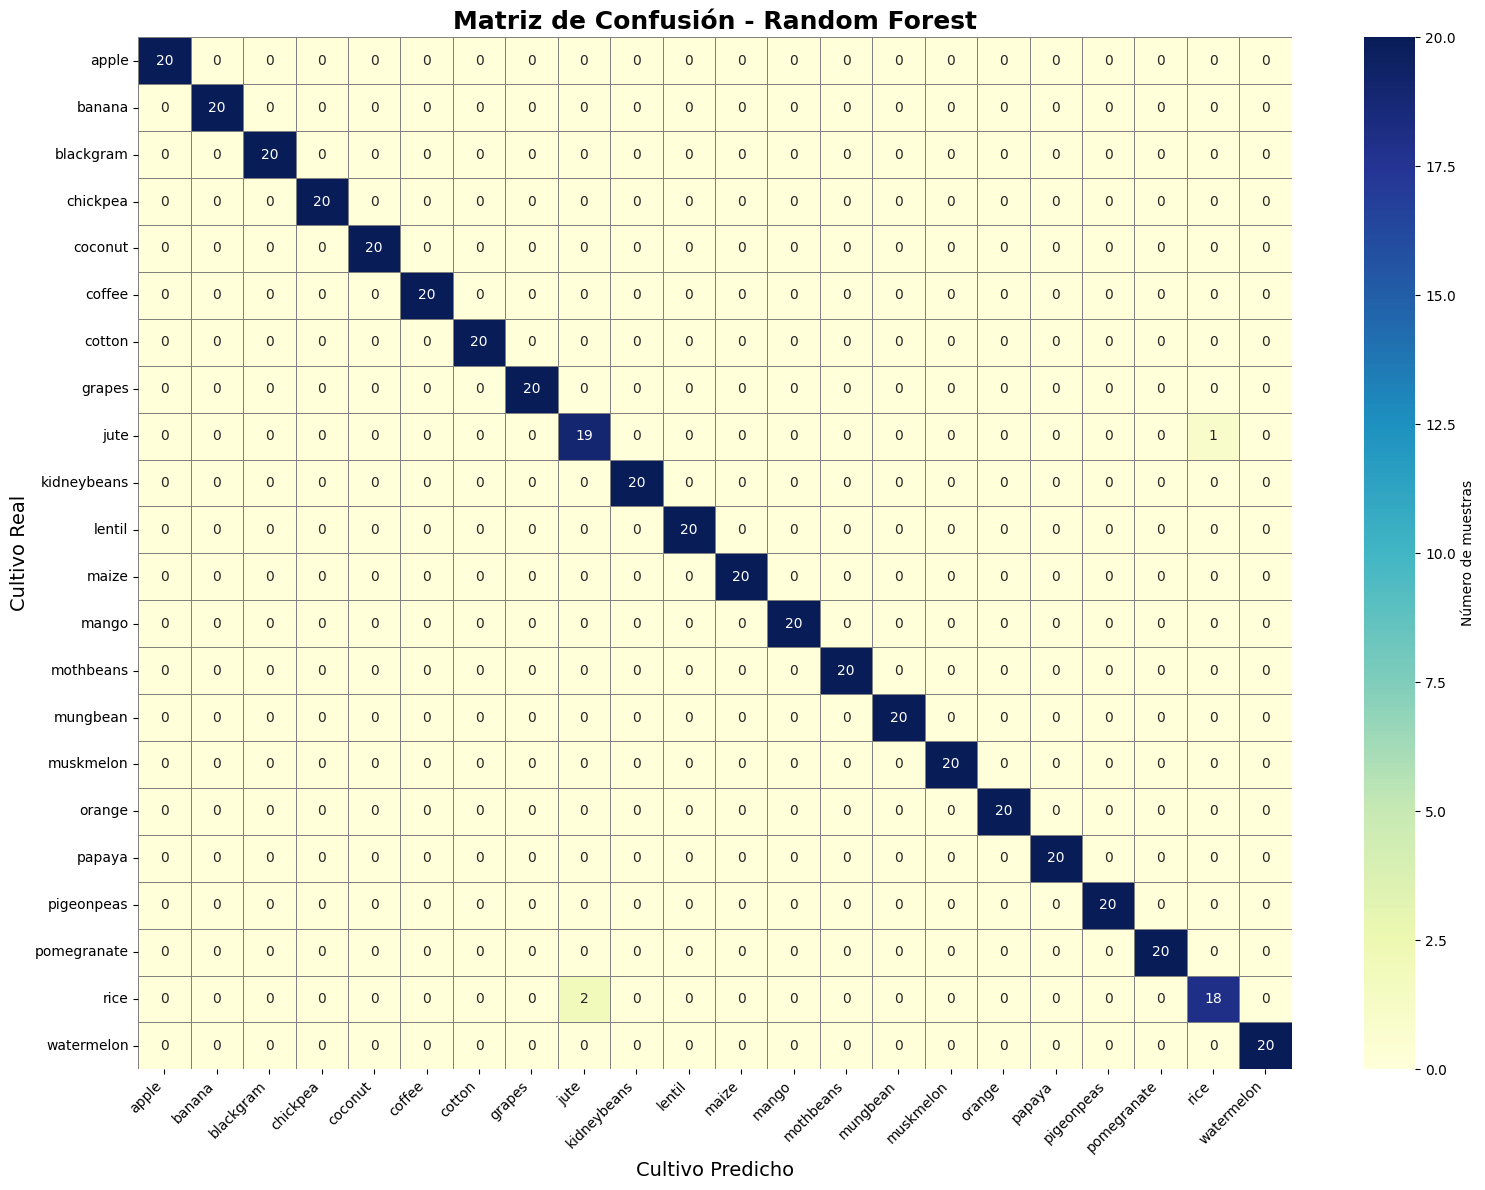

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Número de muestras'},
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(f'Matriz de Confusión - {model_name}', fontsize=18, fontweight='bold')
plt.xlabel('Cultivo Predicho', fontsize=14)
plt.ylabel('Cultivo Real', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


## 11. Guardado de resultados

In [10]:

import os
import joblib

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

metrics_df.to_csv(f"results/metrics_{safe_model_name}.csv", index=False)
report_df.to_csv(f"results/classification_report_{safe_model_name}.csv")

joblib.dump(model, f"models/{safe_model_name}.joblib")
joblib.dump(encoder, "models/label_encoder.joblib")

print("Archivos guardados en las carpetas results/ y models/")


Archivos guardados en las carpetas results/ y models/



## 12. Conclusión parcial

El modelo fue evaluado mediante métricas estándar de clasificación multiclase y mediante latencia de inferencia.

La matriz de confusión permite identificar si el modelo confunde algunos cultivos con condiciones agroclimáticas similares. En general, un buen modelo para este caso de uso debe mantener valores altos de Accuracy, Precision, Recall y F1-score, pero también debe responder con baja latencia para que pueda utilizarse en sistemas de recomendación agrícola en tiempo real o semitiempo real.
